In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve,
                             ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("../data/cleaned/ae_clean.csv", parse_dates=['period'])

print(f"Rows: {len(df)}")
print(f"Columns: {df.columns.tolist()}")

Rows: 4475
Columns: ['period', 'org_code', 'parent_org', 'org_name', 'att_type1', 'att_type2', 'att_other', 'att_booked_type1', 'att_booked_type2', 'att_booked_other', 'over4hr_type1', 'over4hr_type2', 'over4hr_other', 'over4hr_booked_type1', 'over4hr_booked_type2', 'over4hr_booked_other', 'wait_4_12hr', 'wait_12hr_plus', 'emerg_admit_type1', 'emerg_admit_type2', 'emerg_admit_other', 'other_emerg_admit', 'total_attendances', 'total_over4hr', 'pct_within_4hr', 'breach']


In [2]:
# GLOBAL CHART STYLE — run this once, applies to all plots 
import matplotlib.pyplot as plt
import matplotlib as mpl

# NHS colour palette
NHS_BLUE   = '#185FA5'
NHS_DARK   = '#042C53'
NHS_TEAL   = '#1D9E75'
NHS_CORAL  = '#993C1D'
NHS_AMBER  = '#E8A317'
NHS_LIGHT  = '#E6F1FB'
GRAY_TEXT  = '#5F5E5A'
GRAY_LIGHT = '#F1EFE8'

# Global matplotlib settings
mpl.rcParams.update({
    'figure.facecolor'    : 'white',
    'axes.facecolor'      : 'white',
    'axes.edgecolor'      : '#D3D1C7',
    'axes.linewidth'      : 0.8,
    'axes.titlesize'      : 14,
    'axes.titleweight'    : 'bold',
    'axes.titlecolor'     : NHS_DARK,
    'axes.labelsize'      : 11,
    'axes.labelcolor'     : GRAY_TEXT,
    'axes.spines.top'     : False,
    'axes.spines.right'   : False,
    'xtick.labelsize'     : 10,
    'ytick.labelsize'     : 10,
    'xtick.color'         : GRAY_TEXT,
    'ytick.color'         : GRAY_TEXT,
    'legend.fontsize'     : 10,
    'legend.framealpha'   : 0.9,
    'legend.edgecolor'    : '#D3D1C7',
    'figure.dpi'          : 120,
    'savefig.dpi'         : 200,
    'savefig.bbox'        : 'tight',
    'savefig.facecolor'   : 'white',
    'font.family'         : 'sans-serif',
    'grid.color'          : '#E8E6DF',
    'grid.linewidth'      : 0.5,
})


In [3]:
# Redefine breach using 75% threshold — more meaningful for prediction
df['breach'] = (df['pct_within_4hr'] < 75).astype(int)

print(f"New breach rate: {df['breach'].mean()*100:.1f}%")
print(f"Breached (1): {df['breach'].sum()}")
print(f"Not breached (0): {(df['breach']==0).sum()}")

New breach rate: 46.6%
Breached (1): 2084
Not breached (0): 2391


In [4]:
# Sort by trust and date — essential for time-based features
df = df.sort_values(['org_name', 'period']).reset_index(drop=True)

# --- Time features ---
df['month']       = df['period'].dt.month

# Winter flag — Dec, Jan, Feb are historically worst months
df['is_winter']   = df['month'].isin([12, 1, 2]).astype(int)

# Summer flag — Jun, Jul, Aug are historically best months
df['is_summer']   = df['month'].isin([6, 7, 8]).astype(int)

# --- Demand features ---
# Total emergency admissions
df['total_emerg_admit'] = (df['emerg_admit_type1'] +
                            df['emerg_admit_type2'] +
                            df['emerg_admit_other'])

# 12-hour wait rate — serious pressure indicator
df['rate_12hr'] = (df['wait_12hr_plus'] /
                   df['total_attendances'] * 100).round(2)

# Admission rate — how many A&E patients get admitted
df['admission_rate'] = (df['total_emerg_admit'] /
                        df['total_attendances'] * 100).round(2)

# Type 1 share — major A&E as proportion of all attendances
# Type 1 is the most pressured department type
df['type1_share'] = (df['att_type1'] /
                     df['total_attendances'] * 100).round(2)
# NEW — Lag features (last month's data to predict NEXT month's breach)
df['att_lag1']            = df.groupby('org_name')['total_attendances'].shift(1)
df['admission_rate_lag1'] = df.groupby('org_name')['admission_rate'].shift(1)
df['rate_12hr_lag1']      = df.groupby('org_name')['rate_12hr'].shift(1)
df['type1_share_lag1']    = df.groupby('org_name')['type1_share'].shift(1)
df['emerg_admit_lag1']    = df.groupby('org_name')['total_emerg_admit'].shift(1)


print("Features created!")
print(f"\nDataframe shape: {df.shape}")

Features created!

Dataframe shape: (4475, 38)


In [5]:
# Keep only trusts with genuine month-to-month variation
# These are the trusts where prediction actually matters
trust_breach_rate = df.groupby('org_name')['breach'].mean()

uncertain_trusts = trust_breach_rate[
    (trust_breach_rate > 0.1) & 
    (trust_breach_rate < 0.9)
].index

df_model = df[df['org_name'].isin(uncertain_trusts)].copy()

print(f"Trusts kept: {df_model['org_name'].nunique()}")
print(f"Rows: {len(df_model)}")
print(f"Breach rate: {df_model['breach'].mean()*100:.1f}%")

# Verify consistency
trust_check2 = df_model.groupby('org_name')['breach'].mean()
print(f"\nAlways breaching: {(trust_check2 == 1.0).sum()}")
print(f"Never breaching:  {(trust_check2 == 0.0).sum()}")
print(f"Genuinely uncertain: {((trust_check2 > 0.1) & (trust_check2 < 0.9)).sum()}")

Trusts kept: 48
Rows: 1056
Breach rate: 57.2%

Always breaching: 0
Never breaching:  0
Genuinely uncertain: 48


In [6]:
# These are the columns the model will learn from
feature_cols = [
    'month',
    'is_winter',
    'is_summer',
    'total_attendances',
    'att_type1',
    'type1_share',
    'rate_12hr',
    'admission_rate',
    'wait_12hr_plus',
    'total_emerg_admit',
    'att_lag1',             # LAST month's total attendances
    'admission_rate_lag1', # LAST month's admission pressure
    'rate_12hr_lag1',      # LAST month's 12hr wait rate
    'type1_share_lag1',    # LAST month's type 1 share
    'emerg_admit_lag1',    # LAST month's emergency admissions
]

X = df_model[feature_cols]
y = df_model['breach']

print(f"Features: {len(feature_cols)}")
print(f"Total samples: {len(X)}")
print(f"Breach (1): {y.sum()} | No breach (0): {(y==0).sum()}")
print(f"Class balance: {y.mean()*100:.1f}% breach")

Features: 15
Total samples: 1056
Breach (1): 604 | No breach (0): 452
Class balance: 57.2% breach


In [7]:
before = len(df_model)

# Drop any remaining NaN in our actual feature columns
df_model = df_model.dropna(subset=[
    'att_lag1',
    'admission_rate_lag1',
    'rate_12hr_lag1',
    'type1_share_lag1',
    'emerg_admit_lag1',
])

# Redefine X and y after dropping NaN rows
X = df_model[feature_cols]
y = df_model['breach']
after = len(df_model)
print(f"Rows dropped: {before - after}")
print(f"Rows remaining: {after}")
print(f"Breach rate: {df_model['breach'].mean()*100:.1f}%")

Rows dropped: 48
Rows remaining: 1008
Breach rate: 57.0%


In [8]:
split_date = pd.Timestamp('2026-01-01')

train_mask = df_model['period'] < split_date
test_mask  = df_model['period'] >= split_date

X_train = X[train_mask]
X_test  = X[test_mask]
y_train = y[train_mask]
y_test  = y[test_mask]

print(f"Training set: {len(X_train)} rows "
      f"({df_model[train_mask]['period'].min().strftime('%b %Y')} "
      f"to {df_model[train_mask]['period'].max().strftime('%b %Y')})")
print(f"Test set:     {len(X_test)} rows "
      f"({df_model[test_mask]['period'].min().strftime('%b %Y')} "
      f"to {df_model[test_mask]['period'].max().strftime('%b %Y')})")
print(f"\nTrain breach rate: {y_train.mean()*100:.1f}%")
print(f"Test breach rate:  {y_test.mean()*100:.1f}%")

Training set: 874 rows (May 2024 to Dec 2025)
Test set:     134 rows (Jan 2026 to Mar 2026)

Train breach rate: 57.6%
Test breach rate:  53.7%


In [9]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    class_weight='balanced',  # handles class imbalance automatically
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("Random Forest trained!")

# Predict
y_pred_rf   = rf.predict(X_test)
y_proba_rf  = rf.predict_proba(X_test)[:, 1]

# Score
auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f"\nRandom Forest ROC-AUC: {auc_rf:.3f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred_rf,
      target_names=['No breach', 'Breach']))

Random Forest trained!

Random Forest ROC-AUC: 0.792

Classification report:
              precision    recall  f1-score   support

   No breach       0.82      0.50      0.62        62
      Breach       0.68      0.90      0.77        72

    accuracy                           0.72       134
   macro avg       0.75      0.70      0.70       134
weighted avg       0.74      0.72      0.70       134



In [10]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(),
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb.fit(X_train, y_train)
print("XGBoost trained!")

y_pred_xgb  = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

auc_xgb = roc_auc_score(y_test, y_proba_xgb)
print(f"\nXGBoost ROC-AUC: {auc_xgb:.3f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred_xgb,
      target_names=['No breach', 'Breach']))

XGBoost trained!

XGBoost ROC-AUC: 0.818

Classification report:
              precision    recall  f1-score   support

   No breach       0.85      0.55      0.67        62
      Breach       0.70      0.92      0.80        72

    accuracy                           0.75       134
   macro avg       0.78      0.73      0.73       134
weighted avg       0.77      0.75      0.74       134



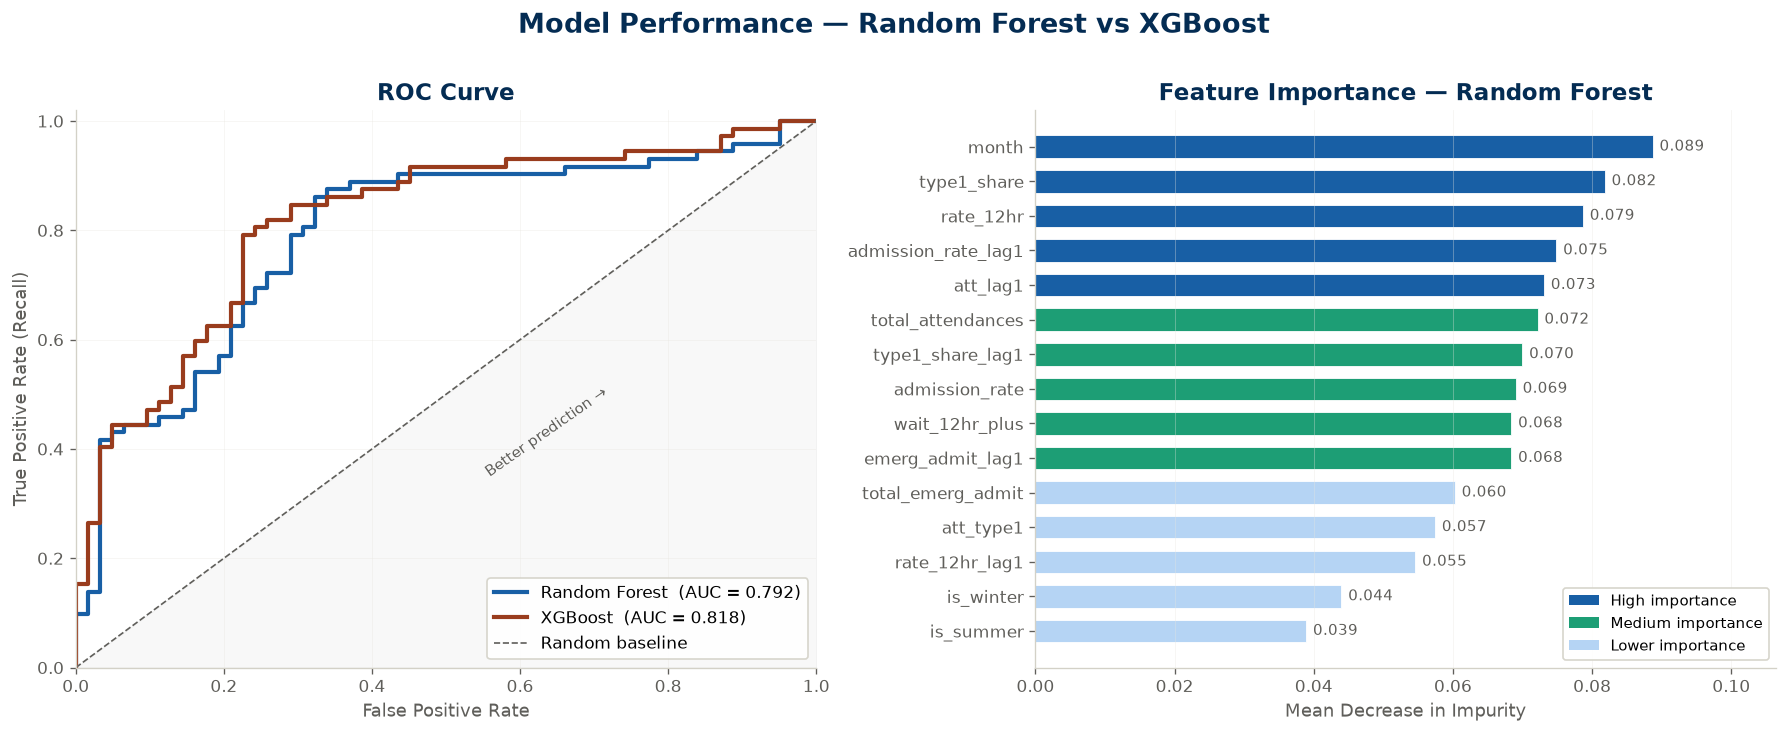

Best model: XGBoost
RF AUC:  0.792
XGB AUC: 0.818


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Model Performance — Random Forest vs XGBoost',
             fontsize=16, fontweight='bold', color=NHS_DARK, y=1.01)

# ROC curves 
colors = [NHS_BLUE, NHS_CORAL]
for (name, proba), color in zip(
        [('Random Forest', y_proba_rf), ('XGBoost', y_proba_xgb)],
        colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, linewidth=2.5, color=color,
                 label=f'{name}  (AUC = {auc:.3f})')

axes[0].plot([0,1],[0,1], linestyle='--', linewidth=1,
             color=GRAY_TEXT, label='Random baseline')
axes[0].fill_between([0,1],[0,1], alpha=0.04, color=GRAY_TEXT)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])
axes[0].grid(True, alpha=0.4)

# Annotate AUC scores
axes[0].annotate('Better prediction →',
                  xy=(0.55, 0.35), fontsize=9,
                  color=GRAY_TEXT, rotation=35)

# Feature importance
feat_imp = pd.Series(
    rf.feature_importances_, index=feature_cols
).sort_values(ascending=True)

# Colour bars by importance rank
bar_colors = [NHS_BLUE if v >= feat_imp.quantile(0.67)
              else NHS_TEAL if v >= feat_imp.quantile(0.33)
              else '#B5D4F4'
              for v in feat_imp.values]

bars = axes[1].barh(feat_imp.index, feat_imp.values,
                    color=bar_colors, edgecolor='white',
                    linewidth=0.5, height=0.65)

# Add value labels on bars
for bar, val in zip(bars, feat_imp.values):
    axes[1].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9,
                 color=GRAY_TEXT)

axes[1].set_title('Feature Importance — Random Forest')
axes[1].set_xlabel('Mean Decrease in Impurity')
axes[1].set_xlim([0, feat_imp.max() * 1.2])
axes[1].grid(True, axis='x', alpha=0.4)

# Legend for colours
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=NHS_BLUE,  label='High importance'),
    Patch(facecolor=NHS_TEAL,  label='Medium importance'),
    Patch(facecolor='#B5D4F4', label='Lower importance'),
]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('../output-files/06_model_comparison.png')
plt.show()

print(f"Best model: {'XGBoost' if auc_xgb > auc_rf else 'Random Forest'}")
print(f"RF AUC:  {auc_rf:.3f}")
print(f"XGB AUC: {auc_xgb:.3f}")

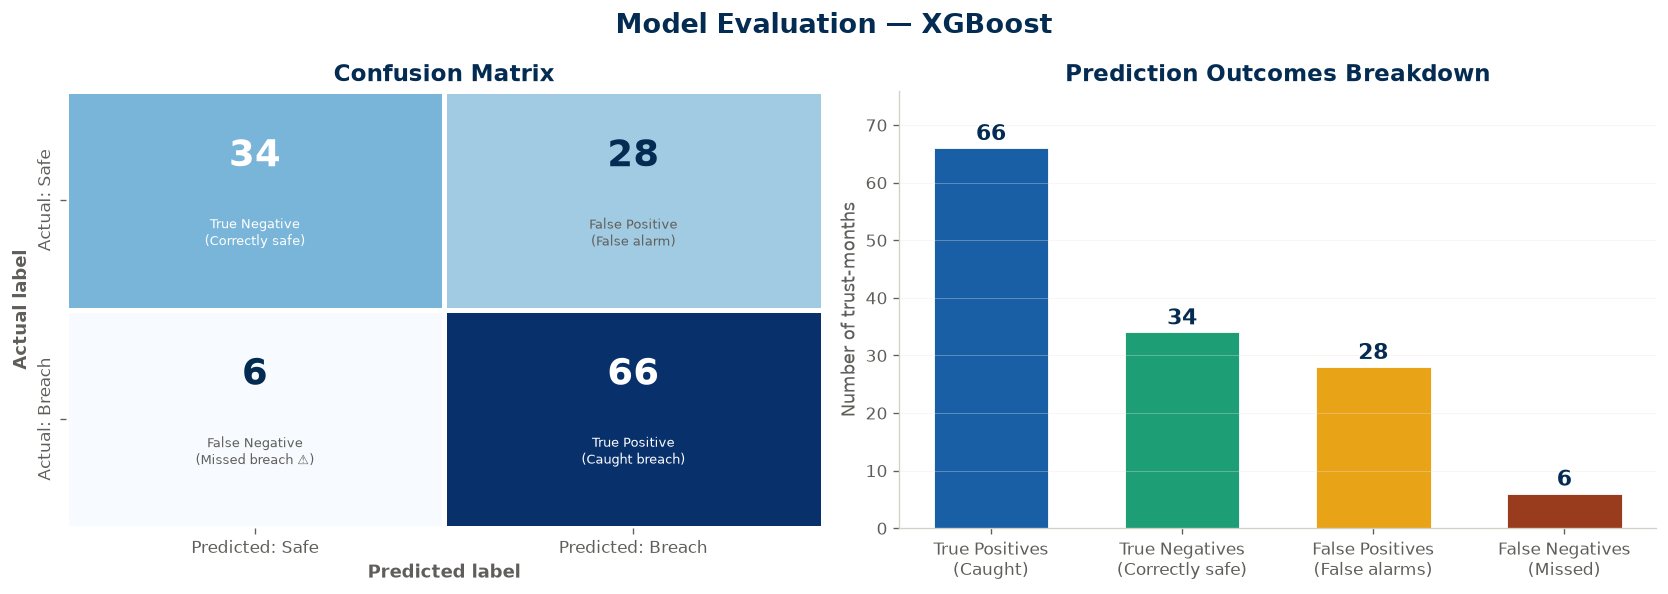


Missed breaches  (FN): 6
False alarms     (FP): 28
Correctly caught (TP): 66
Correctly safe   (TN): 34


In [13]:
best_pred = y_pred_xgb if auc_xgb > auc_rf else y_pred_rf
best_name = 'XGBoost' if auc_xgb > auc_rf else 'Random Forest'

cm = confusion_matrix(y_test, best_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Model Evaluation — {best_name}',
             fontsize=16, fontweight='bold', color=NHS_DARK)

#  Confusion matrix heatmap 
import seaborn as sns

labels = [['True Negative\n(Correctly safe)',
           'False Positive\n(False alarm)'],
          ['False Negative\n(Missed breach ⚠)',
           'True Positive\n(Caught breach)']]

annot = [[f'{tn}\n{labels[0][0]}', f'{fp}\n{labels[0][1]}'],
         [f'{fn}\n{labels[1][0]}', f'{tp}\n{labels[1][1]}']]

cm_colors = [[NHS_TEAL, NHS_AMBER],
             [NHS_CORAL, NHS_BLUE]]

# Use seaborn with custom colormap
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=['Predicted: Safe', 'Predicted: Breach'],
            yticklabels=['Actual: Safe', 'Actual: Breach'],
            ax=axes[0], linewidths=2, linecolor='white',
            cbar=False)

# Add custom annotations
for i in range(2):
    for j in range(2):
        axes[0].text(j + 0.5, i + 0.3,
                     str(cm[i, j]),
                     ha='center', va='center',
                     fontsize=22, fontweight='bold',
                     color='white' if cm[i,j] > cm.max()/2 else NHS_DARK)
        axes[0].text(j + 0.5, i + 0.65,
                     labels[i][j],
                     ha='center', va='center',
                     fontsize=8, color='white' if cm[i,j] > cm.max()/2
                     else GRAY_TEXT)

axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted label', fontweight='bold')
axes[0].set_ylabel('Actual label', fontweight='bold')

#  Summary stats bar chart
categories = ['True Positives\n(Caught)', 'True Negatives\n(Correctly safe)',
              'False Positives\n(False alarms)', 'False Negatives\n(Missed)']
values     = [tp, tn, fp, fn]
colors_bar = [NHS_BLUE, NHS_TEAL, NHS_AMBER, NHS_CORAL]

bars = axes[1].bar(categories, values, color=colors_bar,
                   edgecolor='white', linewidth=0.5, width=0.6)

for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom',
                 fontsize=13, fontweight='bold', color=NHS_DARK)

axes[1].set_title('Prediction Outcomes Breakdown')
axes[1].set_ylabel('Number of trust-months')
axes[1].set_ylim([0, max(values) * 1.15])
axes[1].grid(True, axis='y', alpha=0.4)


plt.tight_layout()
plt.savefig('../output-files/07_confusion_matrix.png')
plt.show()

print(f"\nMissed breaches  (FN): {fn}" )
print(f"False alarms     (FP): {fp}")
print(f"Correctly caught (TP): {tp}")
print(f"Correctly safe   (TN): {tn}")

In [14]:
# Save predictions to a CSV for use in the dashboard later
results = df_model[test_mask][['org_name', 'period',
                           'pct_within_4hr', 'breach']].copy()
results['predicted_breach'] = best_pred
results['breach_probability'] = (y_proba_xgb
                                  if auc_xgb > auc_rf
                                  else y_proba_rf)

results.to_csv('../data/cleaned/model_predictions.csv', index=False)
print("Predictions saved to data/model_predictions.csv")
print(f"\nFinal shape: {results.shape}")
results.head(10)

Predictions saved to data/model_predictions.csv

Final shape: (134, 6)


,org_name,period,pct_within_4hr,breach,predicted_breach,breach_probability
188,BARNSLEY HOSPITAL NHS FOUNDATION TRUST,2026-01-01,63.38,1,1,0.790099
189,BARNSLEY HOSPITAL NHS FOUNDATION TRUST,2026-02-01,75.25,0,1,0.626431
190,BARNSLEY HOSPITAL NHS FOUNDATION TRUST,2026-03-01,80.50,0,1,0.746283
260,BEDFORDSHIRE HOSPITALS NHS FOUNDATION TRUST,2026-01-01,74.53,1,1,0.752690
261,BEDFORDSHIRE HOSPITALS NHS FOUNDATION TRUST,2026-02-01,77.04,0,1,0.949369
262,BEDFORDSHIRE HOSPITALS NHS FOUNDATION TRUST,2026-03-01,79.98,0,0,0.236940
308,BIRMINGHAM WOMEN'S AND CHILDREN'S NHS FOUNDATI...,2026-01-01,77.58,0,0,0.208360
309,BIRMINGHAM WOMEN'S AND CHILDREN'S NHS FOUNDATI...,2026-02-01,77.00,0,0,0.172856
310,BIRMINGHAM WOMEN'S AND CHILDREN'S NHS FOUNDATI...,2026-03-01,76.58,0,0,0.016495
497,BUCKINGHAMSHIRE HEALTHCARE NHS TRUST,2026-01-01,71.68,1,1,0.777903


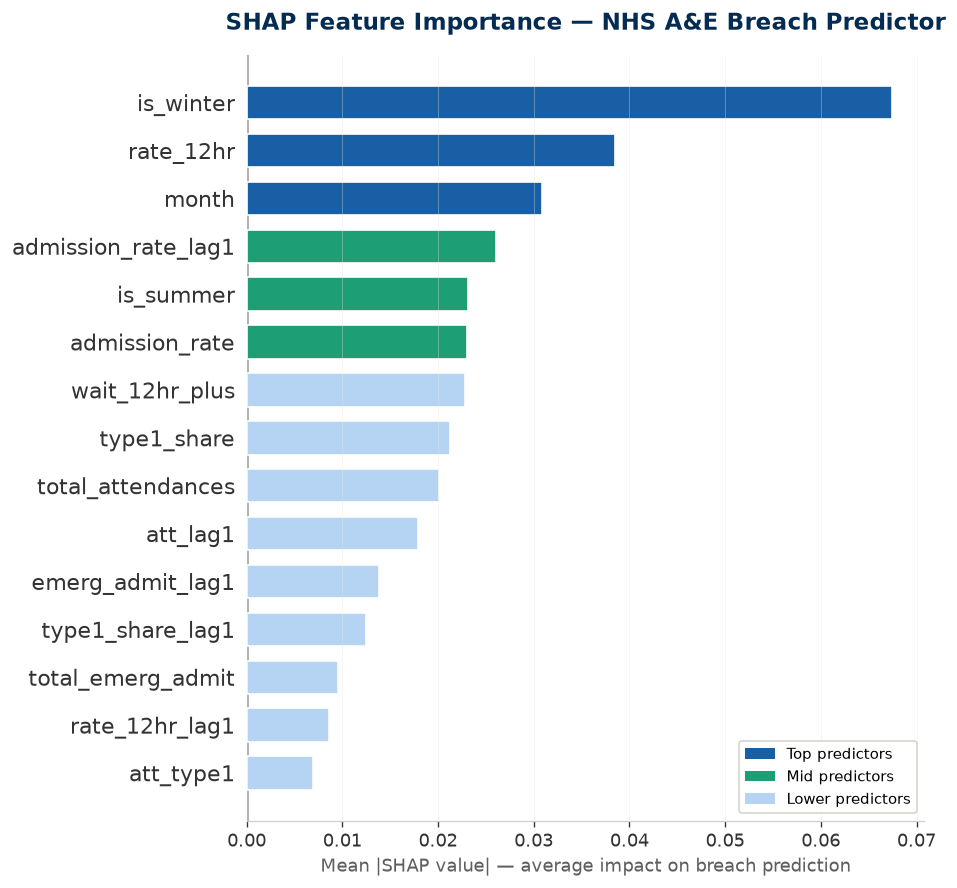

In [15]:
import shap

explainer  = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

fig, ax = plt.subplots(figsize=(10, 6))

shap.summary_plot(
    shap_values[:,:,1], X_test,
    feature_names=feature_cols,
    plot_type='bar',
    color=NHS_BLUE,
    show=False
)

ax = plt.gca()
ax.set_title('SHAP Feature Importance — NHS A&E Breach Predictor',
             fontsize=14, fontweight='bold', color=NHS_DARK, pad=15)
ax.set_xlabel('Mean |SHAP value| — average impact on breach prediction',
              fontsize=11, color=GRAY_TEXT)

# Colour bars by rank
bars = ax.patches
colors_shap = ([NHS_BLUE] * 3 +
               [NHS_TEAL] * 3 +
               ['#B5D4F4'] * (len(bars) - 6))
for bar, color in zip(bars, reversed(colors_shap)):
    bar.set_facecolor(color)
    bar.set_edgecolor('white')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=NHS_BLUE,  label='Top predictors'),
    Patch(facecolor=NHS_TEAL,  label='Mid predictors'),
    Patch(facecolor='#B5D4F4', label='Lower predictors'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
ax.grid(True, axis='x', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../output-files/08_shap_importance.png')
plt.show()

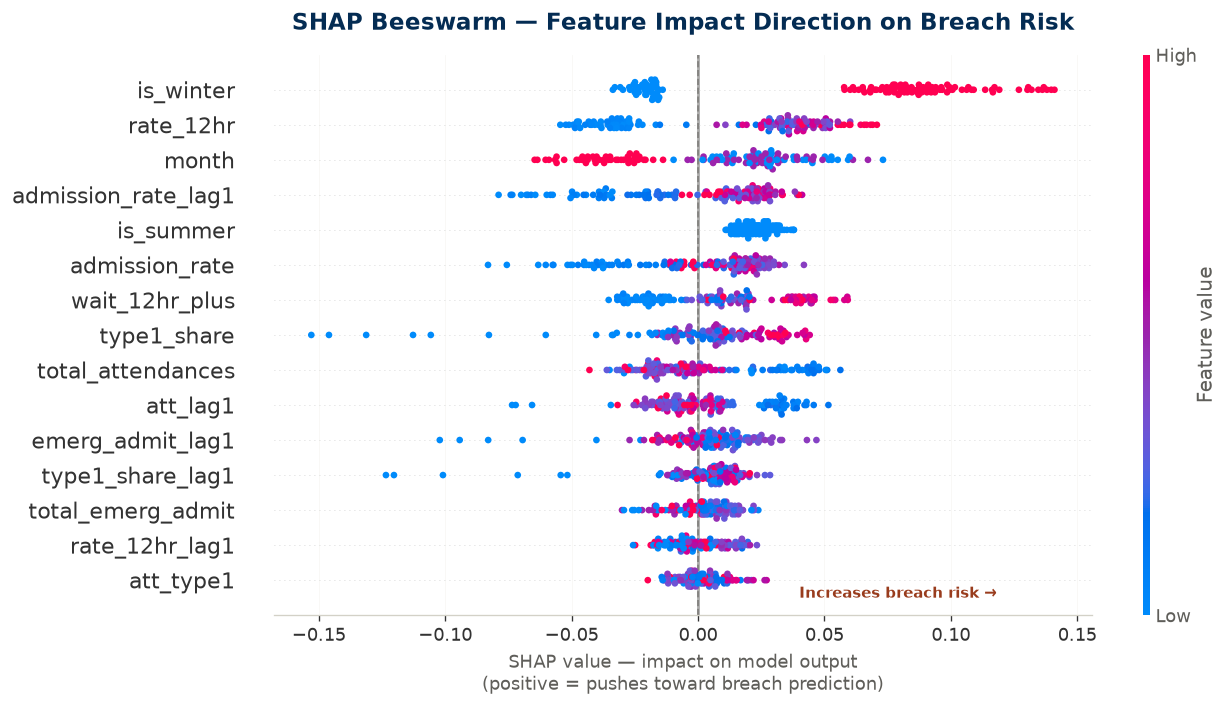

In [16]:
fig, ax = plt.subplots(figsize=(11, 6))

shap.summary_plot(
    shap_values[:,:,1], X_test,
    feature_names=feature_cols,
    show=False,
    plot_size=None,
    color_bar=True
)

ax = plt.gca()
ax.set_title('SHAP Beeswarm — Feature Impact Direction on Breach Risk',
             fontsize=14, fontweight='bold', color=NHS_DARK, pad=15)
ax.set_xlabel('SHAP value — impact on model output\n'
              '(positive = pushes toward breach prediction)',
              fontsize=11, color=GRAY_TEXT)

# Reference line at zero
ax.axvline(x=0, color=GRAY_TEXT, linewidth=1,
           linestyle='--', alpha=0.6, label='No impact')

# Annotations
ax.annotate('← Reduces breach risk',
             xy=(-0.22, -0.5), fontsize=9,
             color=NHS_TEAL, fontweight='bold')
ax.annotate('Increases breach risk →',
             xy=(0.04, -0.5), fontsize=9,
             color=NHS_CORAL, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../output-files/09_shap_beeswarm.png')
plt.show()